Training VAE with β=0.1...
  - Training with latent_dim=2
  - Training with latent_dim=5
  - Training with latent_dim=10
  - Training with latent_dim=20
  - Training with latent_dim=30
  - Training with latent_dim=40
Training VAE with β=0.5...
  - Training with latent_dim=2
  - Training with latent_dim=5
  - Training with latent_dim=10
  - Training with latent_dim=20
  - Training with latent_dim=30
  - Training with latent_dim=40
Training VAE with β=1...
  - Training with latent_dim=2
  - Training with latent_dim=5
  - Training with latent_dim=10
  - Training with latent_dim=20
  - Training with latent_dim=30
  - Training with latent_dim=40
Training VAE with β=2...
  - Training with latent_dim=2
  - Training with latent_dim=5
  - Training with latent_dim=10
  - Training with latent_dim=20
  - Training with latent_dim=30
  - Training with latent_dim=40
Training VAE with β=5...
  - Training with latent_dim=2
  - Training with latent_dim=5
  - Training with latent_dim=10
  - Training with

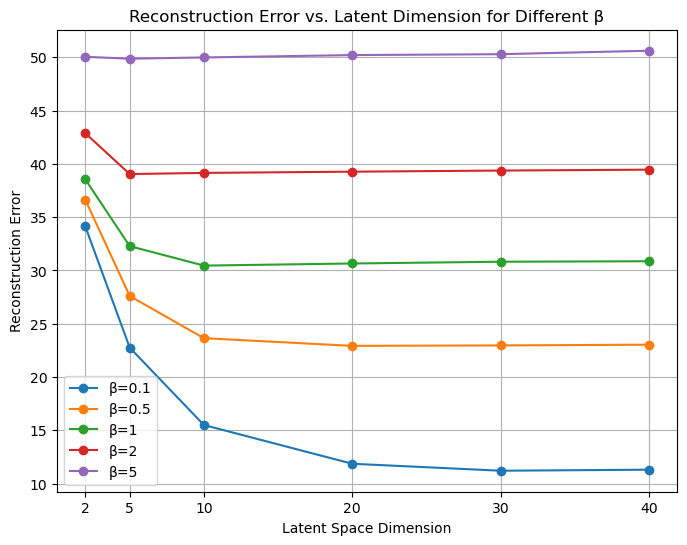

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1️⃣  加载 MNIST 数据集
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])  # 展平 28x28 = 784
train_data = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

# 2️⃣  定义 VAE
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=10):
        super(VAE, self).__init__()
        # 编码器
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc2_logvar = nn.Linear(hidden_dim, latent_dim)

        # 解码器
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc2_mu(h)
        logvar = self.fc2_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))  # 输出范围在 0-1

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 3️⃣  训练 VAE
def train_vae(latent_dim, beta, num_epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    vae = VAE(latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(vae.parameters(), lr=0.001)

    vae.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for batch in train_loader:
            x, _ = batch
            x = x.to(device)
            optimizer.zero_grad()
            recon_x, mu, logvar = vae(x)

            # 计算重构误差 (MSE)
            recon_loss = F.mse_loss(recon_x, x, reduction="sum")
            # 计算 KL 散度
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            # 总损失
            loss = recon_loss + beta * kl_loss

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

    return total_loss / len(train_loader.dataset)  # 仅返回重构误差

# 4️⃣  训练不同 β 值的 VAE，并记录重构误差
latent_dims = [2, 5, 10, 20, 30, 40]
beta_values = [0.1, 0.5, 1, 2, 5]  # 尝试不同 β
results = {beta: [] for beta in beta_values}  # 存储不同 β 的重构误差

for beta in beta_values:
    print(f"Training VAE with β={beta}...")
    for dim in latent_dims:
        print(f"  - Training with latent_dim={dim}")
        recon_error = train_vae(latent_dim=dim, beta=beta)
        results[beta].append(recon_error)

# 5️⃣  绘制不同 β 值下的重构误差曲线
plt.figure(figsize=(8, 6))

for beta, errors in results.items():
    plt.plot(latent_dims, errors, marker="o", linestyle="-", label=f"β={beta}")

plt.xlabel("Latent Space Dimension")
plt.ylabel("Reconstruction Error")
plt.title("Reconstruction Error vs. Latent Dimension for Different β")
plt.xticks(latent_dims)
plt.legend()
plt.grid()
plt.show()
